# Loan Approval Predictor — Analysis & Model Training

**Goal:** Predict whether a loan application should be approved, based
on applicant details such as income, credit history, education, and
property area.

## Workflow

```
Dataset
   |
Preprocessing
   |
Feature Engineering
   |
Model Training
   |
Prediction
```

This notebook covers:
1. Loading & cleaning the Loan Prediction dataset
2. Exploratory Data Analysis (EDA)
3. Feature engineering (income ratios, EMI, etc.)
4. Training and comparing Logistic Regression, Random Forest, and XGBoost
5. Evaluating the best model (accuracy, confusion matrix, feature importance)
6. Saving the trained model for use in `prediction.py` and the Streamlit app


In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
)

from data_preprocessing import load_data, clean_data, TARGET_COL
from feature_engineering import add_engineered_features, encode_and_split, preprocess
from model_training import get_candidate_models, plot_feature_importance

sns.set_style("whitegrid")
%matplotlib inline


## 1. Load & Clean the Data

In [2]:
df_raw = load_data()
print("Raw shape:", df_raw.shape)
df_raw.head()


Raw shape: (491, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP002305,Female,No,0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,1
1,LP001715,Male,Yes,3+,Not Graduate,Yes,5703,0.0,130.0,360.0,1.0,Rural,1
2,LP002086,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.0,1.0,Urban,0
3,LP001136,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,NaN,1.0,Urban,1
4,LP002529,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,1


In [3]:
print("Missing values per column:")
df_raw.isnull().sum()


Missing values per column:


Loan_ID               0
Gender               10
Married               1
Dependents            9
Education             0
Self_Employed        29
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           16
Loan_Amount_Term     13
Credit_History       43
Property_Area         0
Loan_Status           0
dtype: int64

In [4]:
df = clean_data(df_raw)
print("Missing values after cleaning:", df.isnull().sum().sum())
df.head()


Missing values after cleaning: 0


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Female,No,0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,1
1,Male,Yes,3,Not Graduate,Yes,5703,0.0,130.0,360.0,1.0,Rural,1
2,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.0,1.0,Urban,0
3,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,360.0,1.0,Urban,1
4,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,1


## 2. Exploratory Data Analysis

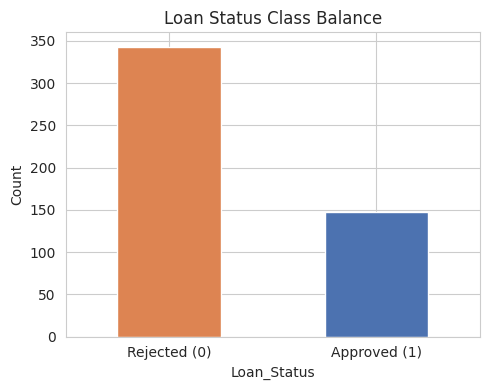

In [5]:
plt.figure(figsize=(5, 4))
df[TARGET_COL].value_counts().plot(kind="bar", color=["#DD8452", "#4C72B0"])
plt.xticks([0, 1], ["Rejected (0)", "Approved (1)"], rotation=0)
plt.ylabel("Count")
plt.title("Loan Status Class Balance")
plt.tight_layout()
plt.show()


<Figure size 600x400 with 0 Axes>

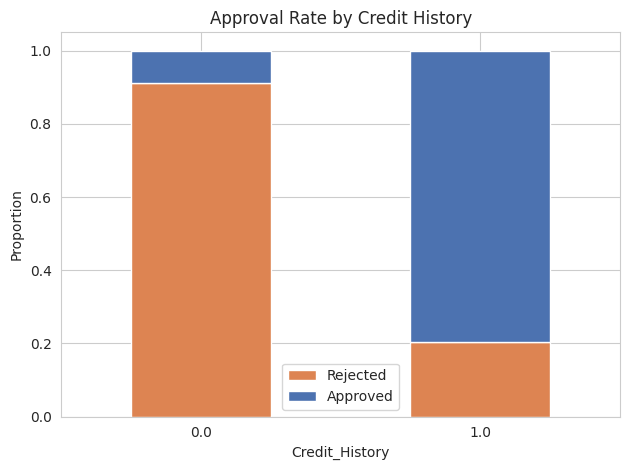

In [6]:
plt.figure(figsize=(6, 4))
approval_by_credit = pd.crosstab(df["Credit_History"], df[TARGET_COL], normalize="index")
approval_by_credit.plot(kind="bar", stacked=True, color=["#DD8452", "#4C72B0"])
plt.ylabel("Proportion")
plt.title("Approval Rate by Credit History")
plt.legend(["Rejected", "Approved"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


<Figure size 600x400 with 0 Axes>

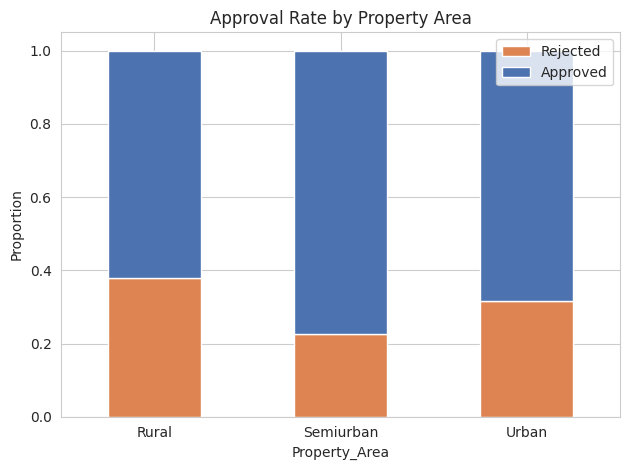

In [7]:
plt.figure(figsize=(6, 4))
approval_by_area = pd.crosstab(df["Property_Area"], df[TARGET_COL], normalize="index")
approval_by_area.plot(kind="bar", stacked=True, color=["#DD8452", "#4C72B0"])
plt.ylabel("Proportion")
plt.title("Approval Rate by Property Area")
plt.legend(["Rejected", "Approved"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 3. Feature Engineering

In [8]:
df_fe = add_engineered_features(df)
df_fe[["ApplicantIncome", "CoapplicantIncome", "TotalIncome",
       "LoanAmount", "LoanAmountToIncome", "EMI", "HasCoapplicant"]].head()


,ApplicantIncome,CoapplicantIncome,TotalIncome,LoanAmount,LoanAmountToIncome,EMI,HasCoapplicant
0,4547,0.0,4547.0,115.0,0.025286,0.319444,0
1,5703,0.0,5703.0,130.0,0.022791,0.361111,0
2,4333,2451.0,6784.0,110.0,0.016212,0.305556,1
3,4695,0.0,4695.0,96.0,0.020443,0.266667,0
4,6700,1750.0,8450.0,230.0,0.027216,0.766667,1


In [9]:
X_train, X_test, y_train, y_test, scaler, feature_names, label_encoder = preprocess()
print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)
print("Features:", feature_names)


Train shape: (392, 18)
Test shape:  (99, 18)
Features: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'TotalIncome', 'LoanAmountToIncome', 'EMI', 'HasCoapplicant', 'Gender_Male', 'Married_Yes', 'Dependents_1', 'Dependents_2', 'Dependents_3', 'Education_Not Graduate', 'Self_Employed_Yes', 'Credit_History_1.0', 'Property_Area_Semiurban', 'Property_Area_Urban']


## 4. Train & Compare Models

In [10]:
models = get_candidate_models()
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = {"model": model, "accuracy": acc}
    print(f"{name:22s} accuracy = {acc:.4f}")


Logistic Regression    accuracy = 0.8485


Random Forest          accuracy = 0.8384
XGBoost                accuracy = 0.7879


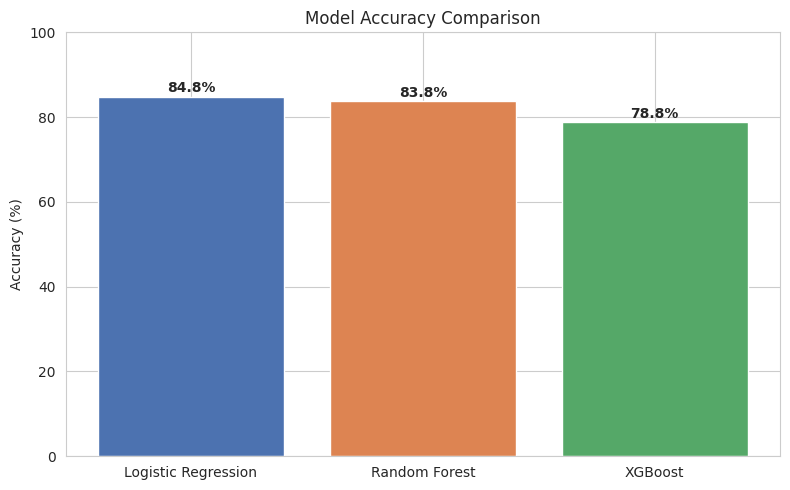

In [11]:
names = list(results.keys())
accs = [results[n]["accuracy"] * 100 for n in names]

plt.figure(figsize=(8, 5))
bars = plt.bar(names, accs, color=["#4C72B0", "#DD8452", "#55A868"])
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 100)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{acc:.1f}%",
             ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


## 5. Evaluate the Best Model

In [12]:
best_name = max(results, key=lambda n: results[n]["accuracy"])
best_model = results[best_name]["model"]
print("Best model:", best_name)

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


Best model: Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.63      0.72        30
           1       0.86      0.94      0.90        69

    accuracy                           0.85        99
   macro avg       0.84      0.79      0.81        99
weighted avg       0.85      0.85      0.84        99

ROC-AUC: 0.855072463768116


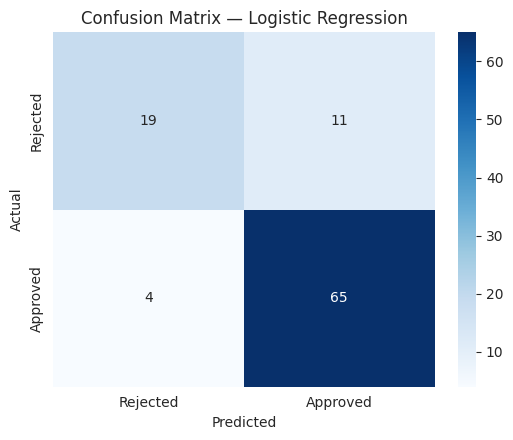

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Rejected", "Approved"],
            yticklabels=["Rejected", "Approved"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()


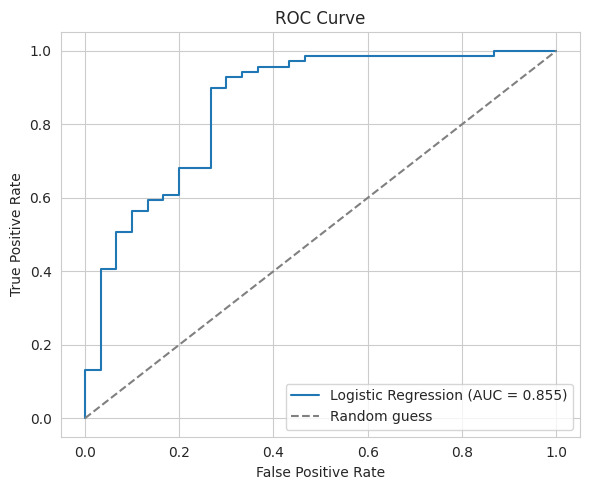

In [14]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"{best_name} (AUC = {roc_auc_score(y_test, y_proba):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Feature Importance

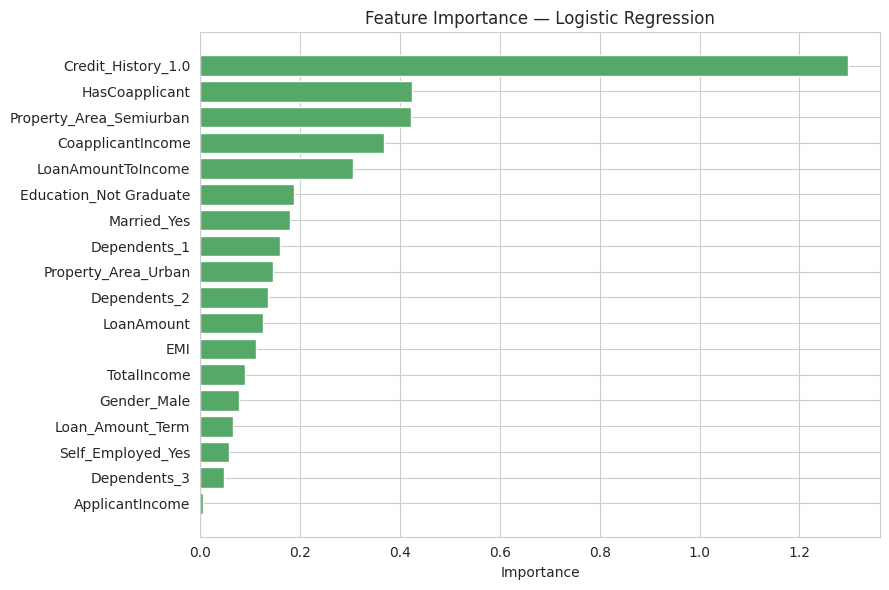

In [15]:
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    importances = np.abs(best_model.coef_[0])
else:
    importances = None

if importances is not None:
    order = np.argsort(importances)[::-1]
    sorted_features = [feature_names[i] for i in order]
    sorted_importances = importances[order]

    plt.figure(figsize=(9, 6))
    plt.barh(sorted_features[::-1], sorted_importances[::-1], color="#55A868")
    plt.xlabel("Importance")
    plt.title(f"Feature Importance — {best_name}")
    plt.tight_layout()
    plt.show()


## 7. Save the Trained Model

In [16]:
import pickle, os

os.makedirs("../outputs", exist_ok=True)
artifact = {
    "model": best_model,
    "scaler": scaler,
    "feature_names": feature_names,
    "label_encoder": label_encoder,
    "model_name": best_name,
    "test_accuracy": results[best_name]["accuracy"],
    "all_results": {n: r["accuracy"] for n, r in results.items()},
}
with open("../outputs/trained_model.pkl", "wb") as f:
    pickle.dump(artifact, f)

print("Model saved to ../outputs/trained_model.pkl")


Model saved to ../outputs/trained_model.pkl


## Conclusion

- Missing values in Gender, Married, Dependents, Self_Employed,
  LoanAmount, Loan_Amount_Term, and Credit_History were imputed
  (mode for categorical, median for numeric).
- Engineered features (TotalIncome, LoanAmountToIncome, EMI,
  HasCoapplicant) captured affordability signal beyond the raw columns.
- Three models were compared (Logistic Regression, Random Forest,
  XGBoost); the best performing model was selected automatically based
  on test accuracy.
- Credit History and Total Income are consistently among the most
  important predictors of loan approval.
- The final model was saved for reuse in `src/prediction.py` and the
  Streamlit web app (`app/streamlit_app.py`).
